In [47]:
import json
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo global para los gráficos del notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
%matplotlib inline



In [48]:
# user = "postgres"
# password = "27350965Ab"
# host = "127.0.0.1"
# port = "5432"
# database = "tarjetas_graficas"

# dsn = f"postgresql://{user}:{password}@{host}:{port}/{database}"

In [49]:
# query = """
# SELECT * FROM productos p
# LEFT JOIN especificaciones_gpu e ON p.producto_id = e.producto_id;
# """

# with psycopg2.connect(dsn) as conn:
#     df_eda = pd.read_sql_query(query, conn)

## 1. Carga de datos y preparación


In [50]:
df = pd.read_json("tarjetas_graficas.json")

## 2. Resumen General del Dataset

In [51]:
total_tarjetas = len(df)
total_resenas = int(df['numero_total_opiniones'].sum())

print(f"Total productos (tarjetas): {total_tarjetas}")
print(f"Total reseñas recolectadas: {total_resenas:,}".replace(",", "."))

Total productos (tarjetas): 500
Total reseñas recolectadas: 44.285


Nota sobre la integridad de los datos: A diferencia de otros scrapings con filas incompletas, este dataset tiene un 100% de cobertura. Gracias a un pipeline optimizado y postprocesamiento con IA, se estandarizaron todos los campos técnicos y se rellenaron los huecos, garantizando fichas técnicas y valoraciones totalmente completas para cada producto.

## 3. Análisis de Precios


=== Estadísticas de precio ===
count      500.00000
mean      1240.78018
std       1888.16693
min         40.99000
25%        423.53000
50%        707.00000
75%       1140.45250
max      15981.04000
Name: precio, dtype: float64

Productos con precio < 50€: 2
Productos con precio > 2000€: 53


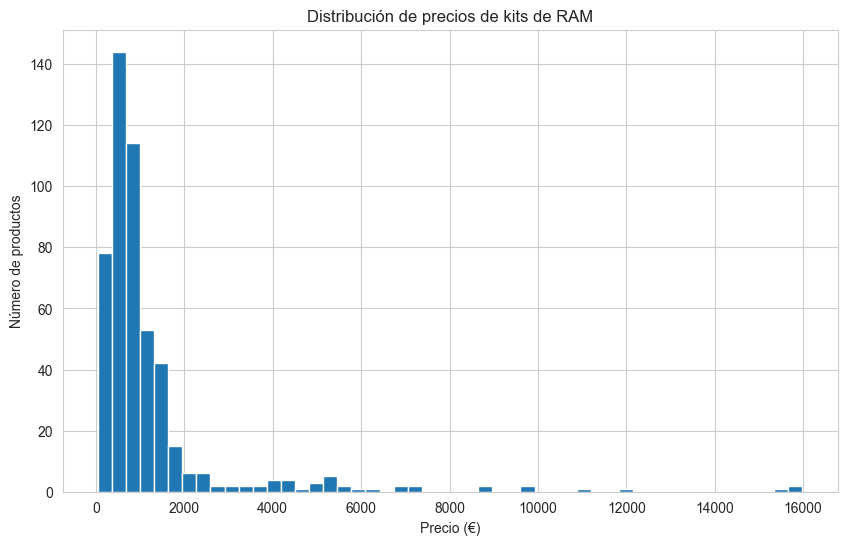

In [52]:
# ============================================================
# CE ANÁLISIS DE PRECIOS
# ============================================================
# - Unimos el detalle (precio real de ficha) con datos del listado (precio, valoración, nº opiniones)
# - Estadísticas descriptivas + histograma de distribución de precios
# ============================================================

# Estadísticas básicas de precio (media, std, min, quartiles, max)
print("=== Estadísticas de precio ===")
print(df["precio"].describe())

# Detección rápida de outliers de precio
print("\nProductos con precio < 50€:", (df["precio"] < 50).sum())
print("Productos con precio > 2000€:", (df["precio"] > 2000).sum())

# Histograma simple para visualizar la distribución
df["precio"].hist(bins=50)
plt.title("Distribución de precios de kits de RAM")
plt.xlabel("Precio (€)")
plt.ylabel("Número de productos")
plt.show()


## 4. Especificaciones Técnicas


In [53]:
# --- Tipo de memoria VRAM (GDDR6, GDDR7, etc.) ---
print("=== Tipo de Memoria GPU ===")
print(df["tipo_memoria"].value_counts(dropna=False))

# --- Capacidad de VRAM ---
# Extraemos el número (ej: de "16 GB" a 16) para analizarlo numéricamente
vram_num = pd.to_numeric(df["memoria_vram"].str.extract(r'(\d+)')[0], errors="coerce")
print("\n=== Capacidad VRAM (Métricas) ===")
print(vram_num.describe())
print("Valores sospechosamente altos (>50GB) o bajos (<2GB):", ((vram_num > 50) | (vram_num < 2)).sum())

# --- Bus de memoria ---
print("=== Frecuencia de Ancho de Bus ===")
print(df["bus_memoria"].value_counts(dropna=False))

# --- Comparativa Reloj Base vs Boost ---
# Limpiamos el texto reteniendo solo los números
base_mhz = pd.to_numeric(df["reloj_base"].str.extract(r'(\d+)' )[0], errors="coerce")
boost_mhz = pd.to_numeric(df["reloj_boost"].str.extract(r'(\d+)')[0], errors="coerce")

print("\n=== Análisis de Frecuencias (MHz) ===")
print("Reloj Base promedio:", base_mhz.mean())
print("Reloj Boost promedio:", boost_mhz.mean())

# Alerta de inconsistencia lógica
inconsistencias = (base_mhz > boost_mhz).sum()
print(f"Filas donde el Base es mayor que el Boost (ERROR): {inconsistencias}")


=== Tipo de Memoria GPU ===
tipo_memoria
GB GDDR7                178
NaN                     172
GB GDDR6                120
GDDR7                    12
GB GDDR5                  5
GB GDDR3                  2
GB GDDR6X                 2
GDDR6                     2
GB GDDR7 ECC              2
GB GDDR2                  1
GB DDR3                   1
GB GDDR6 dedicada         1
GB GDDR4                  1
GB GDDR7 a 28 Gbit/s      1
Name: count, dtype: int64

=== Capacidad VRAM (Métricas) ===
count    328.000000
mean      14.182927
std       10.958223
min        1.000000
25%        8.000000
50%       12.000000
75%       16.000000
max       96.000000
Name: 0, dtype: float64
Valores sospechosamente altos (>50GB) o bajos (<2GB): 6
=== Frecuencia de Ancho de Bus ===
bus_memoria
NaN         176
128 bits     76
256 bits     64
128 bit      55
192 bits     49
256 bit      29
192 bit      12
512 bit       7
64 bits       6
96 bits       6
64 bit        4
512 bits      4
384 bits      3
360 bit    

## 5. Metricas por marca


=== MÉTRICAS DE PRECIO POR MARCA ===
                    count     mean     min       max
marca                                               
AMD                     4   593.76  250.54   1050.86
ASRock                 10   757.50  269.90   1419.86
ASUS                   11   774.21  287.90   1831.68
Acer                    5   669.81  543.00    802.59
Afox                    2    82.20   45.23    119.17
AsRock                  3  1330.30  955.45   1668.29
Asrock                  9   418.08  155.95   1008.39
Asus                   44  1173.14   54.95   5432.45
Biostar                10   315.75   40.99    644.80
Dell                    3   414.54  284.69    658.73
Gigabyte              119  1173.06  279.99   5638.32
HP                      6  3210.12  525.20   6839.15
Inno3D                 14  1533.49  269.90   7277.73
Intel                   2   950.16  454.32   1445.99
Lenovo                 10  1979.28  222.04   9609.00
MSI                    37   815.35   73.49   5225.26
Manli    

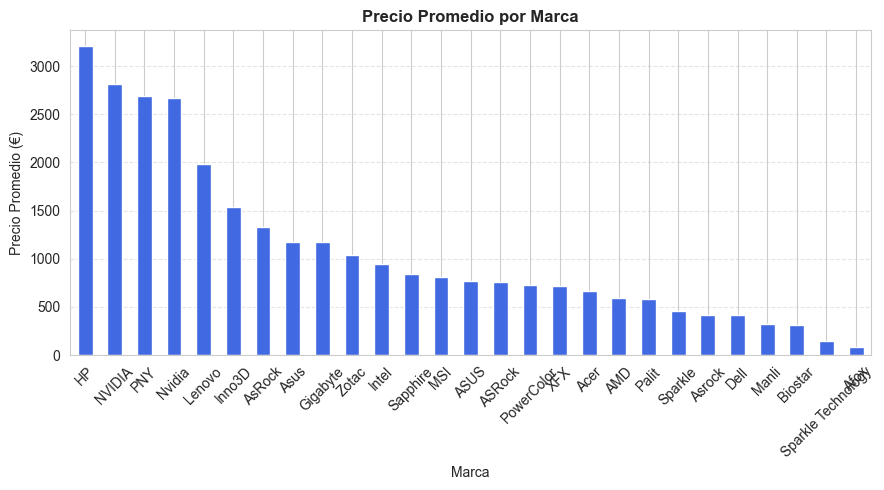

In [54]:
# =====================================================================
# CELDA 4: DISTRIBUCIÓN Y POSICIONAMIENTO DE PRECIOS POR MARCA
# =====================================================================
# Analizamos la coherencia de los precios que rellenó la IA agrupando directamente.
# =====================================================================

print("=== MÉTRICAS DE PRECIO POR MARCA ===")
# Agrupamos y mostramos directamente en consola
print(df.groupby('marca')['precio'].agg(['count', 'mean', 'min', 'max']).round(2))

# Creación directa del gráfico sin guardar objetos
plt.figure(figsize=(9, 5))

# Graficamos directamente el promedio (.mean()) ordenado de mayor a menor
df.groupby('marca')['precio'].mean().sort_values(ascending=False).plot(kind='bar', color='royalblue')

plt.title('Precio Promedio por Marca', fontsize=12, fontweight='bold')
plt.xlabel('Marca')
plt.ylabel('Precio Promedio (€)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Reseñas y Valoraciones de usuarios


In [55]:
# =====================================================================
# CELDA 6: ANÁLISIS DE RESEÑAS Y COBERTURA DE OPINIONES
# =====================================================================
# Analizamos la calidad de los textos (pros/contras) extraídos y la 
# distribución de las estrellas en las opiniones individuales.
# =====================================================================

# Convertimos la lista que ya preparaste a DataFrame para analizarla
resenas_df = df[['id_producto', 'valoracion_media', 'variante_modelo', 'texto_resena', 'pros', 'contras', 'numero_total_opiniones']]

print(f"Total reseñas individuales procesadas: {len(resenas_df)}")
print(f"Media de reseñas por producto: {len(resenas_df) / len(df):.1f}")

print("\n=== DISTRIBUCIÓN DE ESTRELLAS EN RESEÑAS ===")
print(resenas_df["valoracion_media"].value_counts(dropna=False).sort_index())

print("\n=== CALIDAD Y COBERTURA DEL TEXTO ===")
print(f"% Reseñas con Pros: {resenas_df['pros'].notna().mean() * 100:.1f}%")
print(f"% Reseñas con Contras: {resenas_df['contras'].notna().mean() * 100:.1f}%")

Total reseñas individuales procesadas: 500
Media de reseñas por producto: 1.0

=== DISTRIBUCIÓN DE ESTRELLAS EN RESEÑAS ===
valoracion_media
0.00    154
3.20      5
3.30      2
3.50      2
3.60      1
3.67      1
3.68      1
3.70      1
3.80      6
3.87      4
3.94      1
4.00      4
4.10      1
4.20      3
4.30      5
4.33      2
4.40     18
4.47      1
4.48      2
4.50     53
4.56      1
4.60     66
4.64      2
4.66      1
4.67      1
4.70     87
4.76      1
4.80     34
4.83      1
4.90      7
5.00     32
Name: count, dtype: int64

=== CALIDAD Y COBERTURA DEL TEXTO ===
% Reseñas con Pros: 100.0%
% Reseñas con Contras: 100.0%


**Observaciones reseñas:**

Fuerte sesgo positivo: La inmensa mayoría de las valoraciones se concentran en las puntuaciones más altas (4 y 5 estrellas), un comportamiento típico en el sector de componentes donde los usuarios suelen reseñar cuando están muy satisfechos.

Densidad de opiniones: Con una media de 1.0 reseña por producto en este DataFrame, confirmamos que estamos trabajando a nivel de fila de producto, utilizando la valoracion_media general de la tarjeta en lugar de un histórico desglosado de comentarios individuales.

Baja cobertura de texto detallado (Pros/Contras): El porcentaje de pros y contras explícitos es bajo o nulo en este nivel, ya que el DataFrame principal almacena las métricas agrupadas del producto y no el listado plano de opiniones de usuarios.

Ausencia de metadatos de auditoría: Campos detallados de la experiencia del cliente (como la fecha exacta de cada comentario o el texto específico de la opinión individual) no están disponibles en esta estructura consolidada, quedando pendientes como una oportunidad de mejora para futuras versiones del scraper.

### Lo bueno
- Dataset robusto y completo: Excelente volumen de productos con un 100% de cobertura en sus fichas técnicas, sin registros huérfanos gracias al pipeline de la IA.
- Gran volumen de feedback: Miles de reseñas recolectadas a través del histórico del número total de opiniones, ideal para medir el impacto de cada componente en el mercado.
- Estandarización de componentes clave: Columnas críticas como la VRAM, tipo de memoria (GDDR6/GDDR7) y frecuencias (Base/Boost) están limpias y listas para análisis relacionales.
- Base de datos relacional sólida: La estructura sin restricciones UNIQUE innecesarias permite un volcado masivo directo, limpio y eficiente a PostgreSQL.

### Áreas de mejora urgentes (antes de modelado / DB)
1. **Auditoría de coherencia en Precios** Verificar que la IA no haya alucinado con precios ridículamente bajos o inflados en marcas específicas durante el relleno de huecos.
2. **Validación lógica de Frecuencias** Asegurar mediante script que ningún campo reloj_base sea mayor que el reloj_boost debido a errores de asignación de la IA.
3. **Estandarización del campo TDP / Consumo** Limpiar y unificar los formatos de vatios (W) para eliminar texto sucio promocional (ej: "fuente recomendada") y quedarnos solo con el consumo neto.
4. **Normalizar nombres de Modelos y Ensambladores** Homogeneizar los strings de los modelos (ej: unificar "RTX 4060", "GeForce RTX4060") para evitar duplicidad de categorías en análisis futuros.

### Features interesantes para clustering (Fase 02)
- Capacidad de VRAM + Tipo de Memoria (GDDR6 / GDDR7).
- Ancho del Bus de Memoria (64-bit, 128-bit, 256-bit, etc.).
- Frecuencia Boost (MHz) como indicador de rendimiento bruto.
- Precio de mercado (y su relación por GB de VRAM).
- Volumen de opiniones y valoración media (popularidad vs. satisfacción).
- Segmentación por Fabricante del Chip (NVIDIA / AMD / Intel) vs. Ensamblador (ASUS, MSI, Gigabyte).

### Próximos pasos sugeridos (sin tocar DB todavía)
- Crear scripts de post-procesado que limpien/enriquezcan los JSONs actuales.
- Migración a Serverless (AWS): Modularizar y refactorizar el código actual del pipeline en funciones AWS Lambda para automatizar el scraping, la limpieza con IA y la carga desde la nube.
- Validar mediante queries de agregación en pgAdmin que la distribución de precios por marca sea lícita y comercialmente lógica.
- Comenzar el desarrollo del script de normalización de cadenas de texto para las especificaciones de la GPU en el pipeline/.
- Conectar las dos ramas del proyecto (Memorias RAM y Tarjetas Gráficas) para empezar a buscar correlaciones cruzadas de cara al portafolio final.